In [1]:
import numpy as np 

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

from IPython.display import display

In [2]:
customers = pd.read_csv('customers.csv')
items = pd.read_csv('Items.csv')
order_item = pd.read_csv('order_item.csv')
orders = pd.read_csv('orders.csv')

In [3]:
print(f'-> Question 2\n')
print(f'-> Part 1 / Task 1 - Average item price :\n')

items = pd.read_csv('items.csv')
print('average price per item:')
display(items[['item_name', 'item_price']].groupby('item_name').mean())

print(f'\naverage price for all items is -> {float(items['item_price'].mean())}:')

-> Question 2

-> Part 1 / Task 1 - Average item price :

average price per item:


,item_price
item_name,
Action Camera,2694.250
Antivirus Software,4186.620
Blu-Ray Player,3382.860
CCTV Camera,695.710
Camcorder,860.010
Camera,2202.900
Computer Monitor,4076.350
DVD Player,453.850
Dash Camera,1283.990



average price for all items is -> 2222.0826:


In [4]:
print(f'-> Part 1 / Task 2 - Customer who purchased:\n')

customer_purchases = orders.merge(order_item, on='order_id')
customer_purchases = customer_purchases.groupby('customer_id')['quantity'].sum().sort_values(ascending=False)


top_customer_id = customer_purchases.idxmax()

print('\nTop customer ID is ->', top_customer_id)
print()
print('Number of products is ->',customer_purchases.max())
print()
display(customers.loc[customers['id'] == top_customer_id])

-> Part 1 / Task 2 - Customer who purchased:


Top customer ID is -> 138.0

Number of products is -> 45



,id,first_name,last_name,gender,age,nationallity,joining_date,phone_number,email
137,138,Ellary,Ledner,NaN,63.0,Peru,NaN,NaN,eledner3t@latimes.com


In [5]:
print(f'-> Part 1 / Task 3 - Add total_price :\n')

order_item = order_item.merge(items[['id', 'item_price']], how='left', left_on='item_id', right_on='id')

order_item['total_price'] = order_item['quantity'] * order_item['item_price'] 

display(order_item)

-> Part 1 / Task 3 - Add total_price :



,Unnamed: 0,id_x,order_id,item_id,quantity,id_y,item_price,total_price
0,0,1,337,10.0,2,10.0,453.85,907.70
1,1,2,430,27.0,6,27.0,1283.99,7703.94
2,2,3,430,36.0,2,36.0,3256.88,6513.76
3,3,4,508,46.0,1,46.0,1606.65,1606.65
4,4,5,229,27.0,2,27.0,1283.99,2567.98
...,...,...,...,...,...,...,...,...
995,995,996,594,24.0,2,24.0,4449.99,8899.98
996,996,997,330,32.0,8,32.0,1523.27,12186.16
997,997,998,472,10.0,3,10.0,453.85,1361.55
998,998,999,222,29.0,1,29.0,4227.36,4227.36


In [6]:
print(f'-> Part 1 / Task 4 - Display purchases :\n')

order_price = order_item[['order_id', 'quantity', 'total_price']].groupby('order_id').sum()
display(order_price)

-> Part 1 / Task 4 - Display purchases :



,quantity,total_price
order_id,,
1,5,8554.20
2,3,10148.58
3,4,6843.36
4,1,965.20
5,25,63944.94
...,...,...
593,2,2301.74
594,18,62560.06
596,7,17830.10


In [7]:
print(f'-> Part 1 / Task 5 Most expensive, cheapest and average :\n')

print('\nMost expensive sale:', order_item['total_price'].max())

print('\nMost cheapest sale:', order_item['total_price'].min())

print('\nAverage of sales:' ,order_item['total_price'].mean())

-> Part 1 / Task 5 Most expensive, cheapest and average :


Most expensive sale: 40241.43000000001

Most cheapest sale: 241.54

Average of sales: 6728.2549895833345


In [8]:
print(f'-> Part 1 / Task 6 - Pivot Table :\n')

pivot_df = pd.pivot_table(customers,
    values='id',                    
    index='nationallity',
    columns='gender',
    aggfunc='count',
    fill_value=0)

display(pivot_df)

-> Part 1 / Task 6 - Pivot Table :



gender,Agender,Bigender,Female,Genderfluid,Genderqueer,Male,Non-binary,Polygender
nationallity,,,,,,,,
Argentina,1,0,10,1,0,9,0,1
Brazil,0,0,6,0,0,17,2,1
Chile,1,0,14,0,0,9,0,0
China,0,0,4,1,1,9,0,1
France,1,0,15,1,0,10,0,0
Germany,0,0,14,0,1,5,1,1
India,1,0,8,0,0,14,0,0
Isreal,2,1,20,5,1,31,0,2
Italy,0,0,14,0,2,10,0,0


-> Part 2 / Task 1 - Customers by gender :



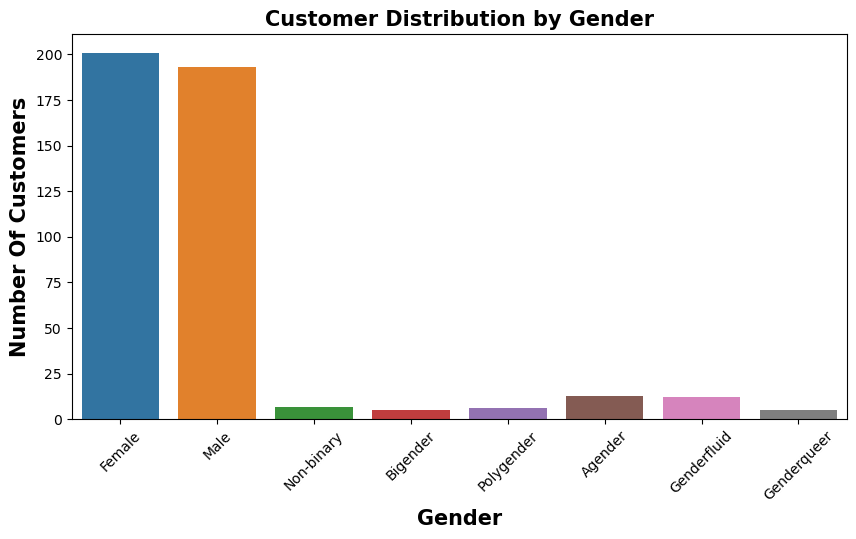

In [9]:
print(f'-> Part 2 / Task 1 - Customers by gender :\n')

gender_data = customers.dropna(subset='gender')

plt.figure(figsize=(10, 5))
sns.countplot(data=gender_data, x='gender', hue='gender')
plt.title('Customer Distribution by Gender', fontsize=15, fontweight='bold')
plt.xlabel('Gender', fontsize=15, fontweight='bold')
plt.ylabel('Number Of Customers', fontsize=15, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

-> Part 2 / Task 2 - Customers by nationality :



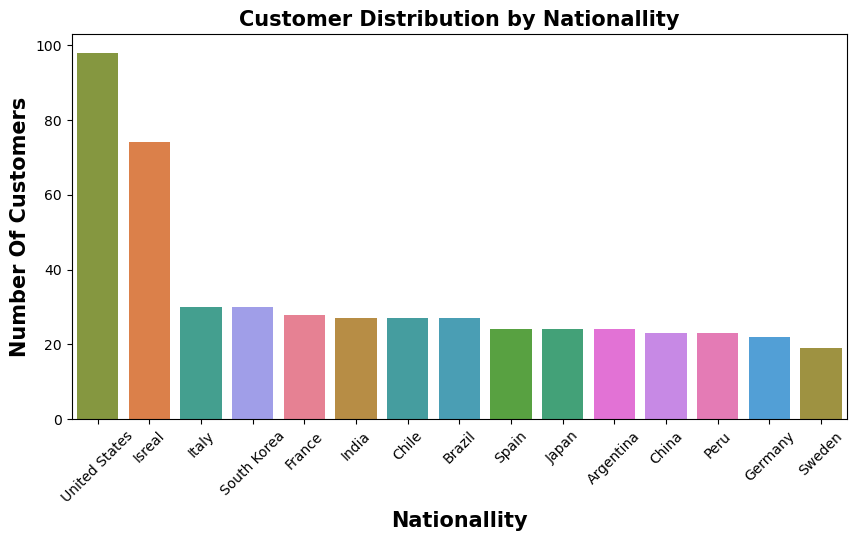

In [10]:
print(f'-> Part 2 / Task 2 - Customers by nationality :\n')

plt.figure(figsize=(10, 5))

nationallity_data = customers.dropna(subset='nationallity')
order = nationallity_data['nationallity'].value_counts().index

sns.countplot(data=nationallity_data, x='nationallity', order=order, hue='nationallity')
plt.title('Customer Distribution by Nationallity', fontsize=15, fontweight='bold')
plt.xlabel('Nationallity', fontsize=15, fontweight='bold')
plt.ylabel('Number Of Customers', fontsize=15, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

-> Part 2 / Task 3 - Customer age histogram :



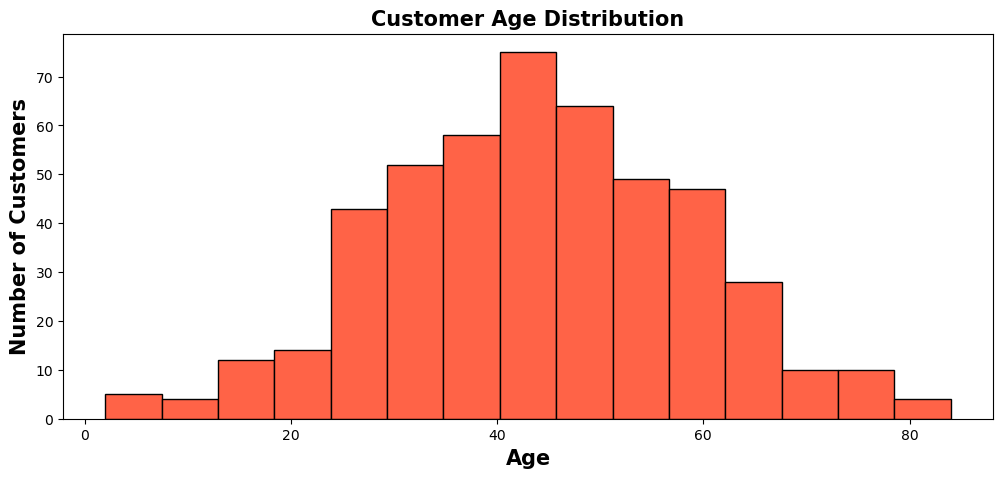

In [11]:
print(f'-> Part 2 / Task 3 - Customer age histogram :\n')

customers['age'].count
age_data = customers['age'].dropna()

plt.figure(figsize=(12, 5))
plt.hist(age_data, bins=15, color='tomato', edgecolor='black')
plt.title('Customer Age Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Age', fontsize=15, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=15, fontweight='bold')
plt.show()

-> Part 2 / Task 4 - New customers by year :



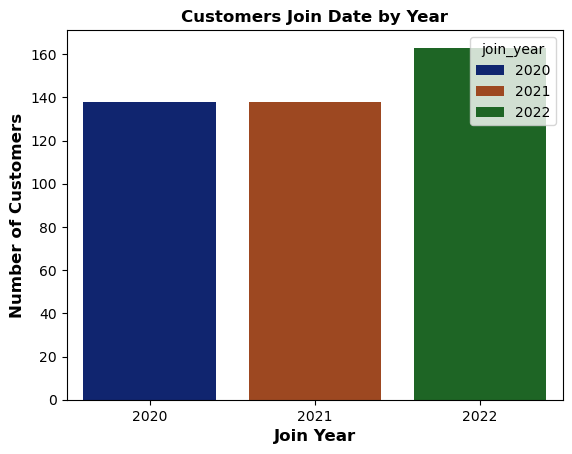

In [12]:
print(f'-> Part 2 / Task 4 - New customers by year :\n')

new_customers = customers.dropna(subset=['joining_date']).copy()
new_customers['join_year'] = pd.to_datetime(new_customers['joining_date'], dayfirst=True).dt.year

sns.countplot(data=new_customers, x='join_year', hue='join_year', palette='dark')
plt.title('Customers Join Date by Year', fontsize=12, fontweight='bold')
plt.xlabel('Join Year', fontsize=12, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=12, fontweight='bold')
plt.show()

-> Part 2 / Task 5 - Sales by month :



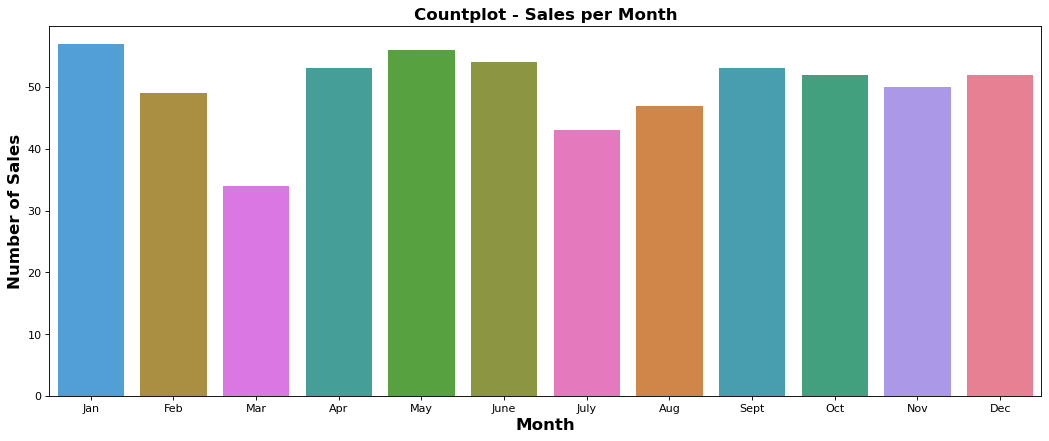

In [13]:
print(f'-> Part 2 / Task 5 - Sales by month :\n')

plt.figure(figsize=(16, 6), dpi=80)

sales = orders[['order_id', 'order_date']].copy()

sales['month'] = pd.to_datetime(sales['order_date']).dt.month

months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']

sales['month'] = sales['month'].replace(np.arange(1, 13), months_order)

sns.countplot(data=sales,x='month', order=months_order, hue='month')

plt.xlabel('Month', fontsize=15, fontweight='bold')
plt.ylabel('Number of Sales', fontsize=15, fontweight='bold')
plt.title('Countplot - Sales per Month', fontsize=15, fontweight='bold')

plt.show()

-> Part 2 / Task 6 - Purchases by age :



<Figure size 1500x400 with 0 Axes>

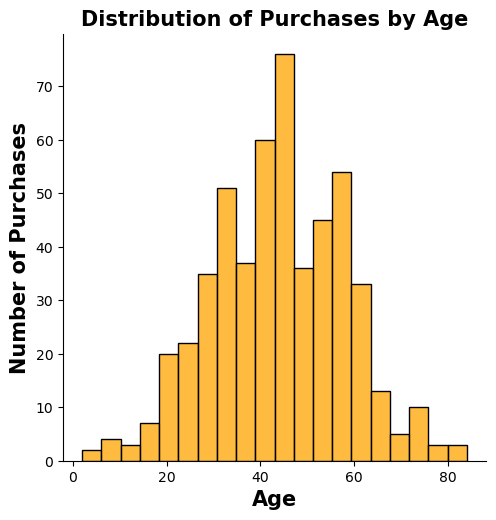

In [14]:
print(f'-> Part 2 / Task 6 - Purchases by age :\n')

plt.figure(figsize=(15, 4))
orders_with_age = orders.merge(customers[['id', 'age']] 
                               ,left_on='customer_id'
                               ,right_on='id',how='left')

orders_with_age = orders_with_age.dropna(subset=['age'])
sns.displot(data=orders_with_age, x='age', bins=20, color='orange')
# plt.hist(orders_with_age['age'], bins=10, edgecolor='black')

plt.title('Distribution of Purchases by Age', fontsize=15, fontweight='bold')
plt.xlabel('Age', fontsize=15, fontweight='bold')
plt.ylabel('Number of Purchases', fontsize=15, fontweight='bold')
plt.show()

-> Part 2 / Task 7 - Challenge Purchase cost by nationality :



,nationallity,total_price
0,United States,1113517.11
1,Isreal,977233.82
2,South Korea,638886.58
3,Chile,467299.35
4,Spain,379117.87
5,France,348308.96
6,Peru,335169.74
7,Italy,316449.81
8,India,309703.67
9,Argentina,304882.30


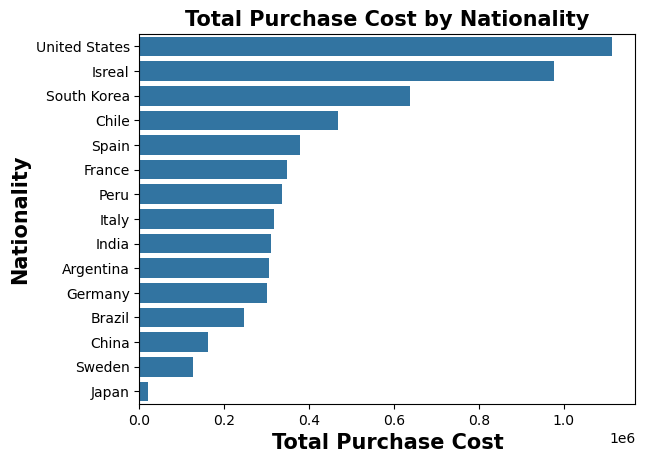

In [15]:
print(f'-> Part 2 / Task 7 - Challenge Purchase cost by nationality :\n')

purchase_data = order_item.merge(orders[['order_id', 'customer_id']], on='order_id',how='left')

purchase_data = purchase_data.merge(customers[['id', 'nationallity']], left_on='customer_id', right_on='id',how='left')

cost_by_nationality = (purchase_data.groupby('nationallity')['total_price'].sum().sort_values(ascending=False).reset_index())

display(cost_by_nationality)

sns.barplot(data=cost_by_nationality, x='total_price', y='nationallity')

plt.xlabel('Total Purchase Cost', fontsize=15, fontweight='bold')
plt.ylabel('Nationality', fontsize=15, fontweight='bold')
plt.title('Total Purchase Cost by Nationality', fontsize=15, fontweight='bold')
plt.show()